# 021 — Training (heteroscedastic / NLL)

Train all four heteroscedastic architectures — `unet_nll`, `resunet_nll`, `attention_unet_nll` (the original pilot, `code-review.md` §7.6), `efficientnet_unet_nll` — on the RGB → IR translation task.
Instead of a single deterministic value per pixel, each model predicts a mean `mu` and a log-variance `log_var`, trained with the Gaussian negative-log-likelihood loss (`scripts.losses.gaussian_nll_loss`).

This notebook mirrors `020_training.ipynb` but is entirely separate: it does not modify or retrain `unet`, `resunet`, `attention_unet`, or `efficientnet_unet` — their checkpoints are untouched.

Checkpoints saved to `models/<arch>_nll/best_model.keras`.
Logs written to `logs/<arch>_nll/` for TensorBoard.

In [1]:
import sys
from pathlib import Path

project_root = Path().absolute()
if project_root.name == "notebooks":
    project_root = project_root.parent
sys.path.insert(0, str(project_root))

In [ ]:
import matplotlib.pyplot as plt
import tensorflow as tf

from scripts.config import settings
from scripts.dataset import (
    build_dataset,
    grouped_train_val_test_split,
    load_image_pairs,
    mockup_aware_train_val_test_split,
)
from scripts.reproducibility import set_global_seed
from scripts.trainer_nll import NLL_LOSSES, compile_model_nll, get_callbacks, get_model_nll
from scripts.visualization import plot_training_curves

# Seed Python / NumPy / TensorFlow from settings.SEED for reproducible runs.
set_global_seed()

gpus = tf.config.list_physical_devices("GPU")
print(f"GPUs available: {gpus}")
print(f"TensorFlow version: {tf.__version__}")

## 1. Build datasets

In [ ]:
# Artworks split logic: every artwork ID (including the paint-on-support
# mockup groups) is a group kept entirely within a single fold, to prevent
# leakage between sections of the same painting. This can hold an entire
# mockup group out of training even though those groups exist to aid it.
pairs = load_image_pairs(settings.IR_DIR, settings.RGB_DIR)
train_pairs, val_pairs, _ = grouped_train_val_test_split(
    pairs,
    train_ratio=settings.TRAIN_RATIO,
    val_ratio=settings.VAL_RATIO,
    seed=settings.SEED,
)

# crop_size only affects the augmented training split; val stays full-image.
train_ds = build_dataset(
    train_pairs,
    batch_size=settings.BATCH_SIZE,
    augment=True,
    shuffle=True,
    seed=settings.SEED,
    crop_size=settings.CROP_SIZE,
)
val_ds = build_dataset(
    val_pairs,
    batch_size=settings.BATCH_SIZE,
    augment=False,
    shuffle=False,
)

print(f"Train: {len(train_pairs)} patches ({len(train_ds)} batches)")
print(f"Val:   {len(val_pairs)} patches ({len(val_ds)} batches)")

In [3]:
# Artwork and mockups split logic (active): real artworks are still
# grouped and leakage-free, but the mockup groups in
# settings.MOCKUP_ARTWORK_IDS are split at the individual pair level, with
# only a small fraction (default 5%) held out for test — the rest is
# available for train/val. Overwrites train_pairs/val_pairs from the block
# above — this is the split the checkpoints in this notebook are trained
# with, matching 020_training.ipynb's active split.
pairs_mockups = load_image_pairs(settings.IR_DIR, settings.RGB_DIR)
train_pairs, val_pairs, _ = mockup_aware_train_val_test_split(
    pairs_mockups,
    train_ratio=settings.TRAIN_RATIO,
    val_ratio=settings.VAL_RATIO,
    mockup_ids=settings.MOCKUP_ARTWORK_IDS,
    seed=settings.SEED,
)

train_ds = build_dataset(
    train_pairs,
    batch_size=settings.BATCH_SIZE,
    augment=True,
    shuffle=True,
    seed=settings.SEED,
    crop_size=settings.CROP_SIZE,
)
val_ds = build_dataset(
    val_pairs,
    batch_size=settings.BATCH_SIZE,
    augment=False,
    shuffle=False,
)

print(f"Train: {len(train_pairs)} patches ({len(train_ds)} batches)")
print(f"Val:   {len(val_pairs)} patches ({len(val_ds)} batches)")

Train: 863 patches (108 batches)
Val:   166 patches (21 batches)


2026-08-12 23:53:27.915176: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4 Max
2026-08-12 23:53:27.915199: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 36.00 GB
2026-08-12 23:53:27.915204: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 14.04 GB
2026-08-12 23:53:27.915215: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-08-12 23:53:27.915223: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


## 2. Loss function

Each of the four NLL architectures outputs two channels per pixel — `mu` (mean, same role as the deterministic models' single output) and `log_var` (log-variance, clipped to `[settings.NLL_LOG_VAR_MIN, settings.NLL_LOG_VAR_MAX]`). The loss is selectable via `LOSS_NAME` below (`scripts.trainer_nll.NLL_LOSSES`):

- `"gaussian_nll"` (default) — plain Gaussian negative-log-likelihood:

  ```
  loss = 0.5 * exp(-log_var) * (y_true - mu) ** 2 + 0.5 * log_var
  ```

  The first term is an uncertainty-weighted squared error; the second penalises inflating `log_var` to trivially shrink the first.
- `"beta_nll"` — the beta-weighted variant from Seitzer et al. 2022 (`scripts.losses.beta_gaussian_nll_loss`), which multiplies the loss above by `stop_gradient(exp(log_var)) ** BETA`. Plain NLL naturally back-propagates a weaker gradient into `mu` wherever `log_var` is high, which can starve high-uncertainty regions of learning signal; beta-weighting counteracts that without changing what's being modeled. `BETA = 0` recovers `"gaussian_nll"` exactly.

See `code-review.md` §7.6 for the full rationale and references (Nix & Weigend 1994; Kendall & Gal 2017; Seitzer et al. 2022).

Metrics (`mae`, `ssim`, `psnr`) are computed from the `mu` channel only (`scripts.metrics.Mu*Metric`) regardless of `LOSS_NAME`, so they stay directly comparable to the deterministic architectures' metrics in `030_evaluation.ipynb` and across different loss choices.

## 3. Train all four NLL architectures

Set `EPOCHS = 2` for a quick smoke test before committing to a full run.
Set `LOSS_NAME` to one of `scripts.trainer_nll.NLL_LOSSES` (`"gaussian_nll"` or `"beta_nll"`); `BETA` only matters when `LOSS_NAME == "beta_nll"`.

Checkpoint paths (`models/<arch>/best_model.keras`) don't encode the loss used to train them — rerunning this notebook with a different `LOSS_NAME` overwrites whatever checkpoint was there before, same as rerunning with different hyperparameters. Rename or move existing checkpoints first if you want to keep both.

In [ ]:
ARCHS = ["unet_nll", "resunet_nll", "attention_unet_nll", "efficientnet_unet_nll"]
EPOCHS = settings.EPOCHS  # -- lower for a quick smoke test
LOSS_NAME = "gaussian_nll"  # one of scripts.trainer_nll.NLL_LOSSES
BETA = 0.5  # only used when LOSS_NAME == "beta_nll"

assert LOSS_NAME in NLL_LOSSES, f"LOSS_NAME must be one of {NLL_LOSSES}"

histories: dict = {}

for arch in ARCHS:
    print(f"\n{'=' * 60}")
    print(f"  Architecture: {arch}")
    print(f"  Loss: {LOSS_NAME}" + (f" (beta={BETA})" if LOSS_NAME == "beta_nll" else ""))
    print(f"{'=' * 60}")

    model = get_model_nll(arch)
    model = compile_model_nll(
        model, lr=settings.LEARNING_RATE, loss_name=LOSS_NAME, beta=BETA
    )
    model.summary(line_length=80)

    callbacks = get_callbacks(
        arch,
        log_dir=settings.LOGS_DIR,
        model_dir=settings.MODELS_DIR,
    )

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS,
        callbacks=callbacks,
        verbose=1,
    )
    histories[arch] = history.history

    best_val_loss = min(history.history["val_loss"])
    print(f"\nBest val_loss ({arch}): {best_val_loss:.4f}")

## 4. Training curves

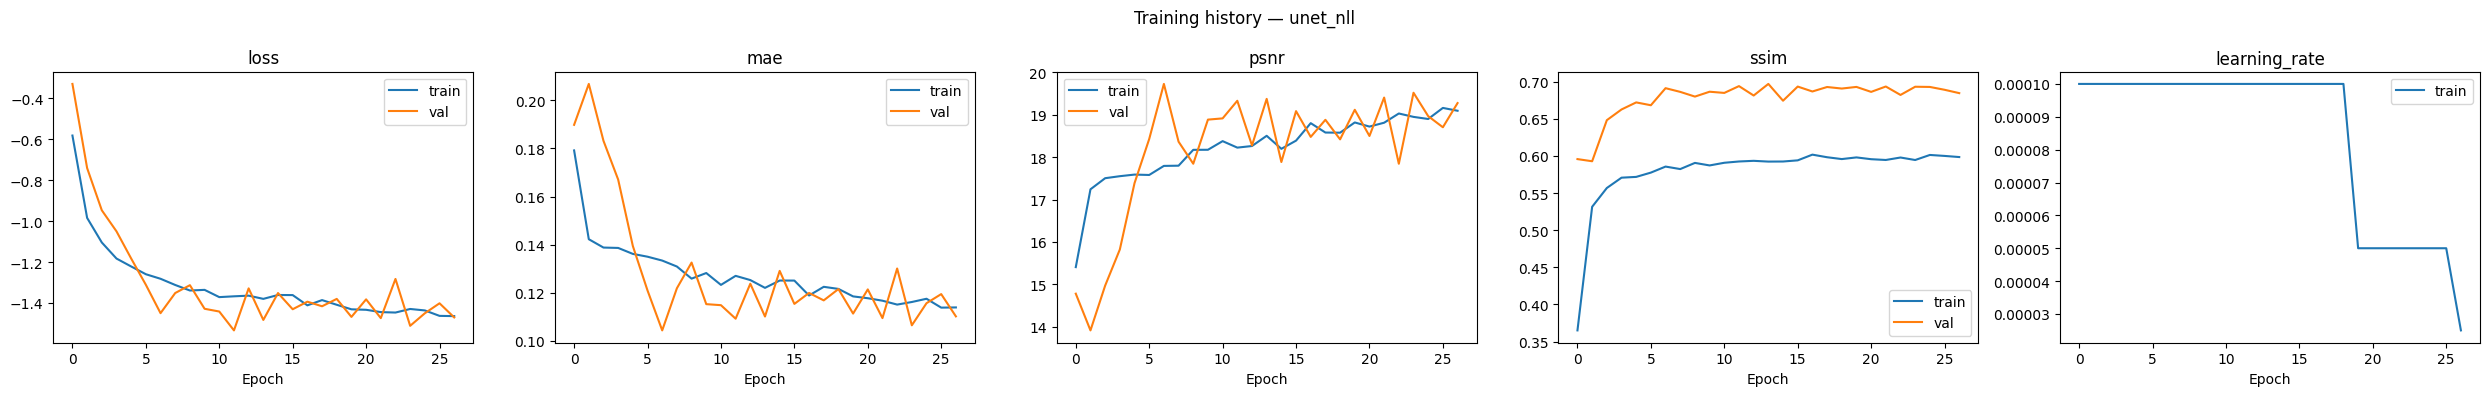

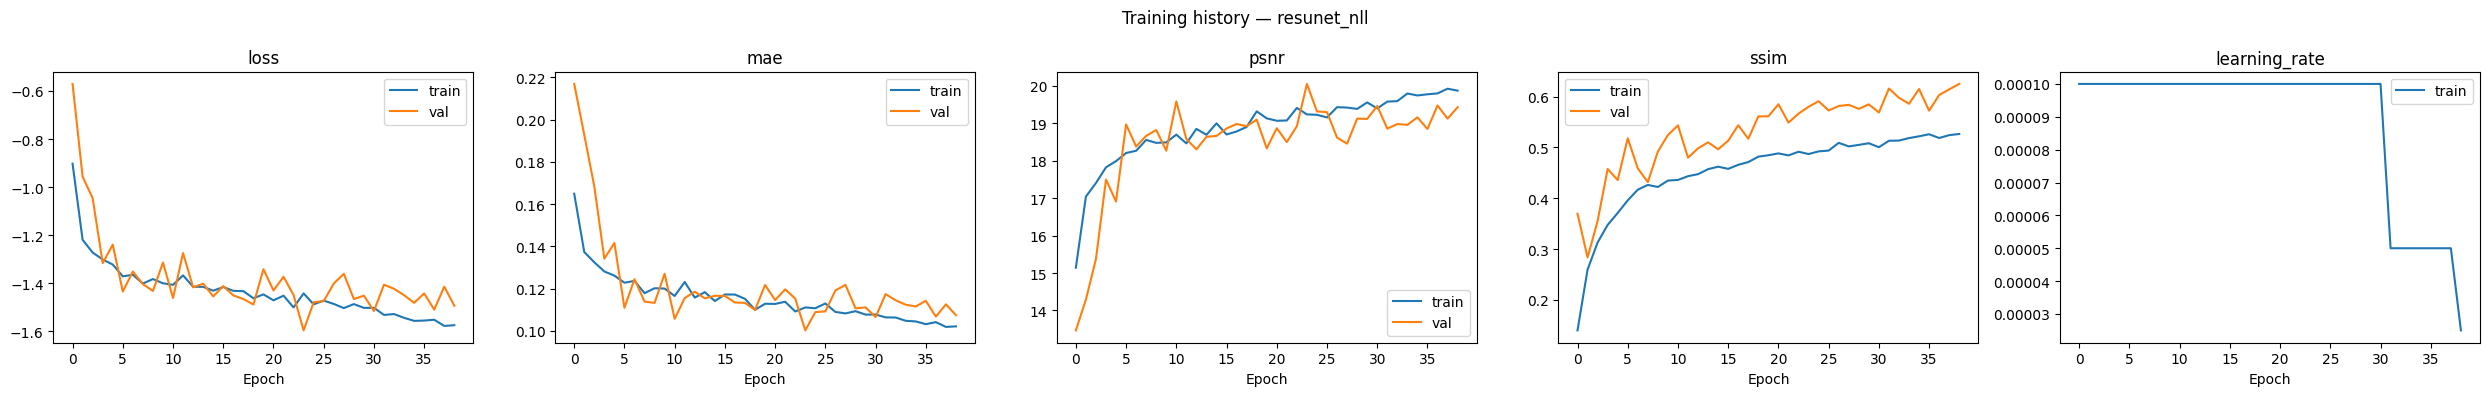

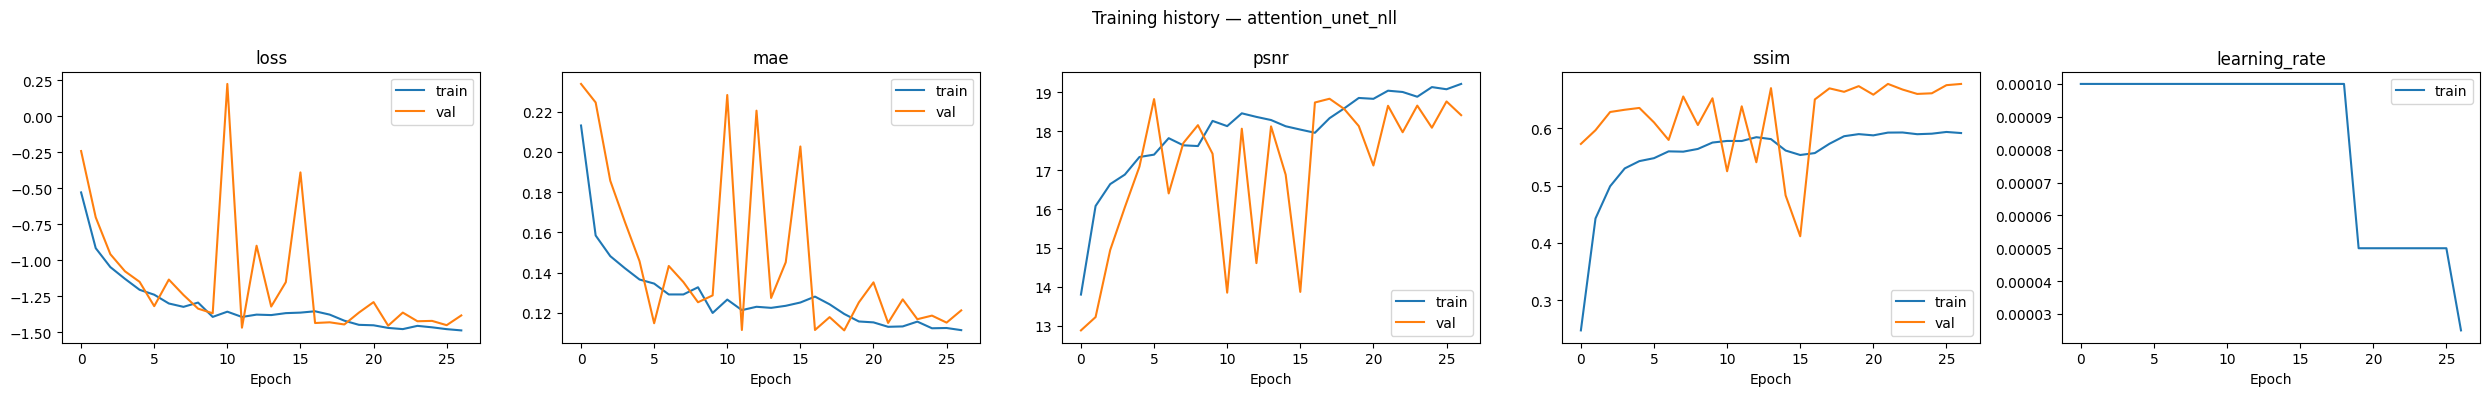

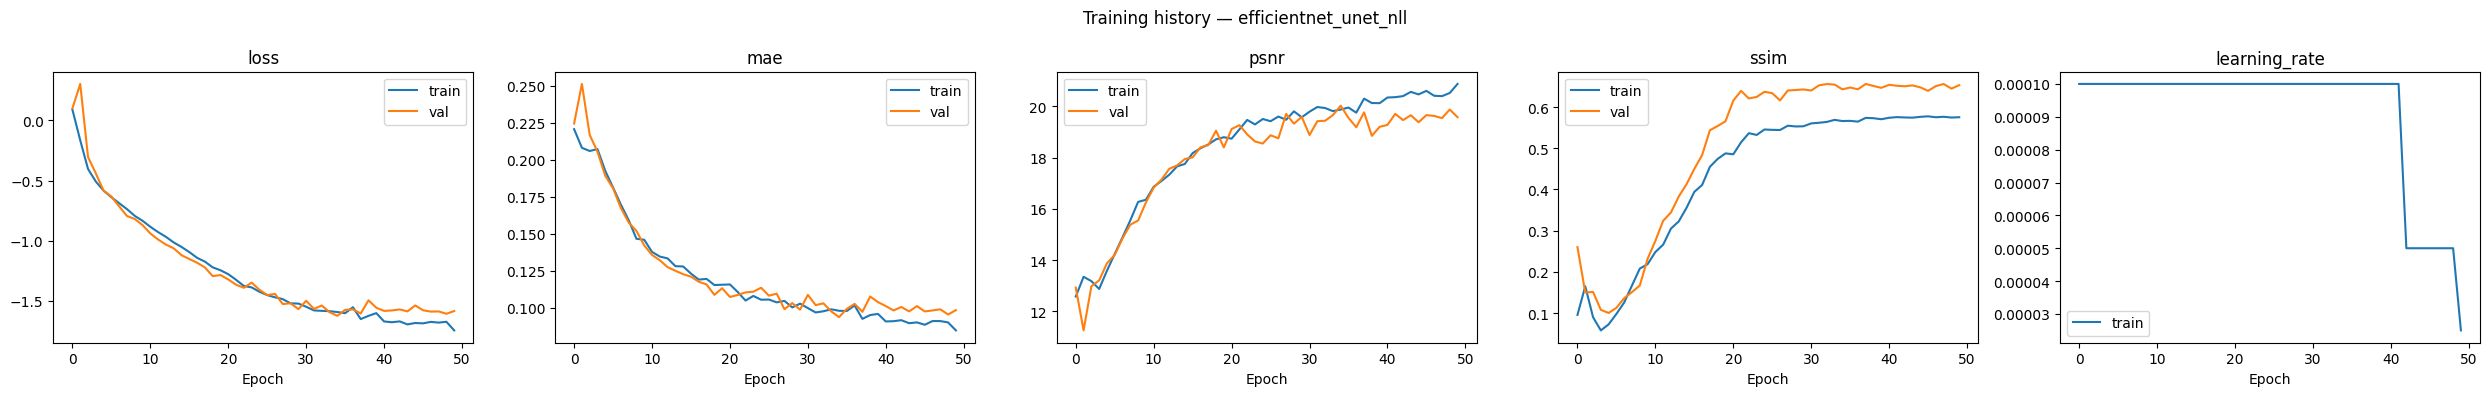

In [5]:
for arch, history in histories.items():
    fig = plot_training_curves(history, title=f"Training history — {arch}")
    plt.show()

## 5. Summary

Checkpoints saved to `models/<arch>/best_model.keras`.  
Run `tensorboard --logdir logs/` to inspect curves interactively.

In [6]:
for arch in ARCHS:
    ckpt = settings.MODELS_DIR / arch / "best_model.keras"
    status = "found" if ckpt.exists() else "MISSING"
    print(f"{arch:<25}: {status}  ({ckpt})")

unet_nll                 : found  (/Users/simonecaglio/Documents/GitHub/deep_layers/models/unet_nll/best_model.keras)
resunet_nll              : found  (/Users/simonecaglio/Documents/GitHub/deep_layers/models/resunet_nll/best_model.keras)
attention_unet_nll       : found  (/Users/simonecaglio/Documents/GitHub/deep_layers/models/attention_unet_nll/best_model.keras)
efficientnet_unet_nll    : found  (/Users/simonecaglio/Documents/GitHub/deep_layers/models/efficientnet_unet_nll/best_model.keras)
